In [1]:
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
class GIN(torch.nn.Module):
    """GIN"""
    def __init__(self, dim_h):
        super(GIN, self).__init__()
        self.conv1 = GINConv(
            Sequential(Linear(dataset.num_node_features, dim_h),
                       BatchNorm1d(dim_h), ReLU(),
                       Linear(dim_h, dim_h), ReLU()))
        self.conv2 = GINConv(
            Sequential(Linear(dim_h, dim_h), BatchNorm1d(dim_h), ReLU(),
                       Linear(dim_h, dim_h), ReLU()))
        self.conv3 = GINConv(
            Sequential(Linear(dim_h, dim_h), BatchNorm1d(dim_h), ReLU(),
                       Linear(dim_h, dim_h), ReLU()))
        self.lin1 = Linear(dim_h*3, dim_h*3)
        self.lin2 = Linear(dim_h*3, dataset.num_classes)

    def forward(self, x, edge_index, batch):
        # Node embeddings
        h1 = self.conv1(x, edge_index)
        h2 = self.conv2(h1, edge_index)
        h3 = self.conv3(h2, edge_index)

        # Graph-level readout
        h1 = global_add_pool(h1, batch)
        h2 = global_add_pool(h2, batch)
        h3 = global_add_pool(h3, batch)

        # Concatenate graph embeddings
        h = torch.cat((h1, h2, h3), dim=1)

        # Classifier
        h = self.lin1(h)
        h = h.relu()
        h = F.dropout(h, p=0.5, training=self.training)
        h = self.lin2(h)

        return h, F.log_softmax(h, dim=1)

# gcn = GCN(dim_h=32)
gin = GIN(dim_h=32)

In [ ]:
def PlotGraph(G):
    pos = nx.kamada_kawai_layout(G)

    plt.figure(figsize=(4, 3))

    nx.draw(
        G, pos,
        with_labels=True,
        node_size=1000,
        node_color='lightblue',
        font_size=8,
        font_weight='bold',
        edge_color='gray',
        width=0.8,
        alpha=0.8
    )

    edge_labels = {}
    for u, v, data in G.edges(data=True):
        w = data.get('weight', '')
        if (u, v) in edge_labels:
            edge_labels[(u, v)] += f",{str(w)}"
        else:
            edge_labels[(u, v)] = str(w)

    nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=7)
    plt.show()


# Graph Neural Networks Expressive Power :

## Separability :


Encode the following graphs to match the input format of the GIN model you implemented in the previous session (remember to consider the adjacency matrix).

<img src="image/graph.png" width="600"></img>

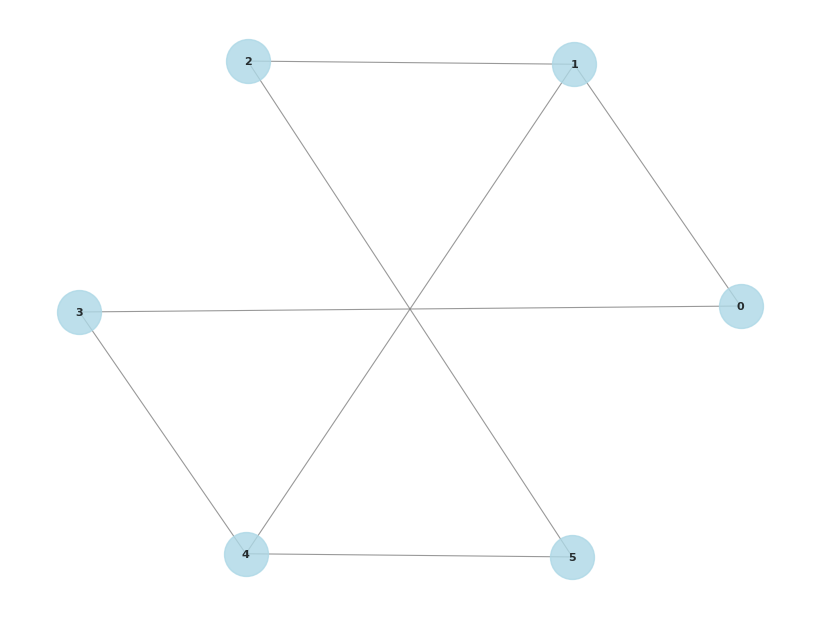

In [7]:
g1 = nx.Graph()
g1.add_node(0)
g1.add_node(1)
g1.add_node(2)
g1.add_node(3)
g1.add_node(4)
g1.add_node(5)
g1.add_edge(1,0)
g1.add_edge(1,2)
g1.add_edge(1,4)
g1.add_edge(4,3)
g1.add_edge(4,5)
g1.add_edge(3,0)
g1.add_edge(2,5)

PlotGraph(g1)

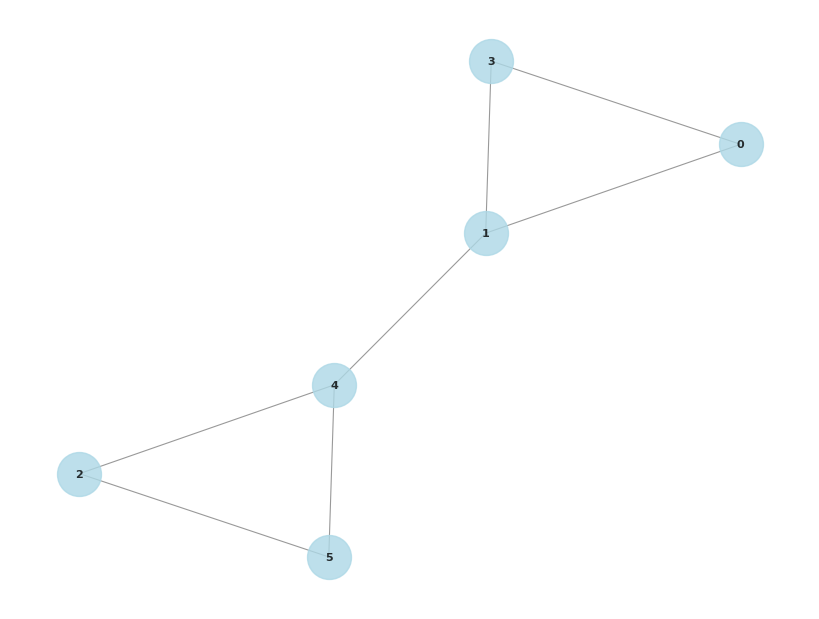

In [8]:
g2 = nx.Graph()
g2.add_node(0)
g2.add_node(1)
g2.add_node(2)
g2.add_node(3)
g2.add_node(4)
g2.add_node(5)
g2.add_edge(1,0)
g2.add_edge(1,3)
g2.add_edge(1,4)
g2.add_edge(4,2)
g2.add_edge(4,5)
g2.add_edge(3,0)
g2.add_edge(2,5)

PlotGraph(g2)

Using the GIN model implemented during the previous practical session, analyze the inference results on the two graphs shown below. 
Can you provide an explanation for the observed outcomes?

In [ ]:
model = GINModel(...)  # Use the same arguments as when you created `gin`

# Load weights
model.load_state_dict(torch.load("gin_model.pth", map_location=torch.device('cpu')))
model.eval()

## Counting power :
Execute the command bellow to load the dataset.

In [2]:
from preparecounting import ExpressiveDataset

dataset = ExpressiveDataset('dataset/subgraphcount')

ModuleNotFoundError: No module named 'torch_geometric'

The task for this dataset is binary classification. To address this, you will utilize the GIN model implemented in the previous practical session. However, prior to model training, the dataset must be split into training, validation, and test sets.

In [ ]:
train_loader = ...
val_loader = ...
test_loader = ...

Generate the confusion matrix for the predictions made by your model.

Does GIN achieved good results on this task?

Now, using PyTorch or by designing your own layer based on the lecture on expressive power, develop a GNN capable of solving this task. You can modify either the input features or the model architecture.

Hint: Pay close attention to the title of this section for guidance.


In [ ]:
Your_Model = 

Can you explain why your model managed to resolve this task?